# Foundational model for timeseries forecasting


### Setup & Config

In [53]:
import sys, os
from pathlib import Path

# Add project root to sys.path to allow imports from src
def find_project_root(start: Path, markers: tuple[str, ...] = ("pyproject.toml", ".git"), max_up: int = 8) -> Path:
    """Walk upward from `start` until a directory containing any marker is found."""
    p = start.resolve()
    for _ in range(max_up):
        if any((p / m).exists() for m in markers):
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(f"Could not find project root above {start} (looked for {markers})")

PROJECT_ROOT = find_project_root(Path(os.getcwd()))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

assert (PROJECT_ROOT / "src" / "config.py").exists(), \
    f"config.py not found under detected project root {PROJECT_ROOT}"
print(f"Project root: {PROJECT_ROOT}")

# Standard / third-party
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import torch
from typing import Dict
from sqlalchemy import create_engine
from chronos import BaseChronosPipeline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Project
from src.config import DIR_DATA_RAW, DIR_DB_SILVER, DIR_DB_GOLD
from src.utils.m_nb_results_to_gold_export import f_nb_results_to_gold_export, f_list_gold_tables
from src.utils.m_query_database import f_query_database
from src.utils.m_sbi_classifier import f_split_by_sbi

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Forecasting config ----
HORIZON       = 3                       # quarters ahead
N_ORIGINS     = 12                      # walk-forward test origins
QUANTILES = [0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]   # 50%, 80%, 95% prediction interval levels
SEASON_LENGTH = 4                       # quarterly seasonality
MIN_HISTORY   = 40                      # min quarters required to include a sector

# ---- Chronos-Bolt config ----
MODEL_ID = "amazon/chronos-bolt-base"
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE    = torch.bfloat16 if DEVICE == "cuda" else torch.float32

# ---- COVID anomaly window (flag only, not removed) ----
COVID_START = pd.Timestamp("2020-03-31")  # Q1 2020 end
COVID_END   = pd.Timestamp("2022-06-30")  # Q2 2022 end

print(f"Device: {DEVICE} | dtype: {DTYPE}")
print(f"Horizon={HORIZON}, Origins={N_ORIGINS}, Quantiles={QUANTILES}")

# Settings
pl.Config(
    tbl_cols=-1,        # Show all columns
    tbl_rows=20,        # Show 20 rows
    tbl_width_chars=10000  # Prevent truncation due to width limit
)

Project root: C:\Git\eaisi-uwv
Device: cpu | dtype: torch.float32
Horizon=3, Origins=12, Quantiles=[0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]


### Ingestion

In [54]:
# ---- Load baseline predictions ----
query = """
SELECT * FROM prediction_baseline_total
UNION ALL
SELECT * FROM prediction_baseline_sbi
UNION ALL
SELECT * FROM prediction_baseline_compsize
"""
df_baseline_all = f_query_database(DIR_DB_GOLD, query, "pandas")
df_baseline_all["period_enddate"] = pd.to_datetime(df_baseline_all["period_enddate"])
df_baseline_all["sbi_code"] = df_baseline_all["sbi_code"].astype(str)

print(f"Baseline rows loaded: {len(df_baseline_all):,}")
print(f"Baseline date range:  {df_baseline_all['period_enddate'].min().date()} → "
      f"{df_baseline_all['period_enddate'].max().date()}")
print(f"Baseline sectors:     {df_baseline_all['sbi_code'].nunique()}")

# SQL Query to extract and format absenteeism data
query = """ 
SELECT 
    Perioden as timeperiod_text, 
    BedrijfskenmerkenSBI2008  as sbi_code,
    BedrijfskenmerkenSBI2008_Title as sbi_title,
    DATE(
        printf('%s-%s-01', 
            substr(Perioden, 1, 4), 
            CASE substr(Perioden, 7, 2)
                WHEN '01' THEN '01'
                WHEN '02' THEN '04'
                WHEN '03' THEN '07'
                WHEN '04' THEN '10'
            END
        ), 
        '+3 months', 
        '-1 day'
    ) AS period_enddate,
    CAST(substr(Perioden, 1, 4) as INTEGER) as "year",
    CAST(substr(Perioden, 8, 1) as INTEGER) as "quarter",
    CAST(Ziekteverzuimpercentage_1 AS REAL) as absenteeism_perc
FROM "80072ned_silver"
WHERE Perioden NOT LIKE '%JJ%' 
AND substr(Perioden, 1, 4) >= '2003'
order by sbi_code, Period_enddate asc
"""
df_org = f_query_database(DIR_DB_SILVER, query, "polars")

df_modified = df_org.with_columns(
    # Convert columns ending with 'date' to Date type
    cs.ends_with("date").str.to_date("%Y-%m-%d"),
)

df_modified.sort("period_enddate", descending=True).head()
# ---- Automated split using f_split_by_sbi ---
# The function auto-detects CBS internal keys and splits into one DataFrame
# per hierarchy level using the CBS dimension JSON as reference.
# Note: f_split_by_sbi works with pandas, so we convert Polars -> Pandas -> Polars.
dim_json_path = Path(DIR_DATA_RAW) / "80072ned" / "BedrijfskenmerkenSBI2008.json"
sbi_splits = f_split_by_sbi(
    df=df_modified.to_pandas(),
    sbi_column="sbi_code",
    dimension_json_path=dim_json_path,
)
# Convert each split back to Polars and assign to named variables
df_total    = pl.from_pandas(sbi_splits["df_totaal"]) # pl.col("sbi_code") == "T001081")
df_sbi_lvl1 = pl.from_pandas(sbi_splits["df_section"]) # pl.col("sbi_title").str.to_uppercase().str.contains(r"^[A-U]\s"))
df_compsize = pl.from_pandas(sbi_splits["df_size"]) # pl.col("sbi_code") .is_in(["WP19098", "WP19091", "WP19078"]))

# Show all available splits and their row counts
print("Available splits:")
for name, sub_df in sbi_splits.items():
    print(f"  {name}: {len(sub_df)} rows")

df_total.head()

✅ Query returned 1265 rows from gold_data.db as pandas DataFrame


✅ Query returned 3549 rows from silver_data.db as polars DataFrame


Baseline rows loaded: 1,265
Baseline date range:  2012-03-31 → 2025-09-30
Baseline sectors:     23
Available splits:
  df_section: 1729 rows
  df_sector: 273 rows
  df_size: 273 rows
  df_subdivision: 1183 rows
  df_totaal: 91 rows


timeperiod_text,sbi_code,sbi_title,period_enddate,year,quarter,absenteeism_perc
str,str,str,datetime[ms],i64,i64,f64
"""2003KW01""","""T001081""","""A-U Alle economische activitei…",2003-03-31 00:00:00,2003,1,5.3
"""2003KW02""","""T001081""","""A-U Alle economische activitei…",2003-06-30 00:00:00,2003,2,4.6
"""2003KW03""","""T001081""","""A-U Alle economische activitei…",2003-09-30 00:00:00,2003,3,4.1
"""2003KW04""","""T001081""","""A-U Alle economische activitei…",2003-12-31 00:00:00,2003,4,4.8
"""2004KW01""","""T001081""","""A-U Alle economische activitei…",2004-03-31 00:00:00,2004,1,4.7


In [55]:
def to_wide(df: pl.DataFrame, label: str) -> pd.DataFrame:
    """Pivot long CBS frame to wide: index=period_enddate, columns=sbi_code."""
    wide = (
        df.select(["period_enddate", "sbi_code", "absenteeism_perc"])
          .sort("period_enddate")
          .pivot(values="absenteeism_perc", index="period_enddate", on="sbi_code")
          .to_pandas()
          .set_index("period_enddate")
          .sort_index()
    )
    wide.index = pd.DatetimeIndex(wide.index, name="period_enddate")
    print(f"[{label}] shape={wide.shape} | range={wide.index.min().date()} → {wide.index.max().date()}")
    return wide

def qa_report(wide: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per-sector QA: n_obs, first/last quarter, internal gaps, NaN count."""
    full_idx = pd.date_range(wide.index.min(), wide.index.max(), freq="QE-DEC")
    rows = []
    for col in wide.columns:
        s = wide[col].dropna()
        if s.empty:
            rows.append({"sbi_code": col, "n_obs": 0, "first": None, "last": None,
                         "internal_gaps": None, "nan_in_span": None}); continue
        span = full_idx[(full_idx >= s.index.min()) & (full_idx <= s.index.max())]
        rows.append({
            "sbi_code": col,
            "n_obs": int(s.shape[0]),
            "first": s.index.min().date(),
            "last":  s.index.max().date(),
            "internal_gaps": int(len(span) - len(s)),         # missing quarters inside the series' own span
            "nan_in_span":   int(wide[col].reindex(span).isna().sum()),
        })
    qa = pd.DataFrame(rows).sort_values("n_obs", ascending=False).reset_index(drop=True)
    print(f"\n[{label}] QA summary:")
    print(qa.to_string(index=False))
    return qa

def truncate_to_contiguous_tail(wide: pd.DataFrame) -> pd.DataFrame:
    """For each sector, drop everything before the last internal gap.
    Returns wide frame where each column is a contiguous tail (NaN-padded at the start)."""
    full_idx = pd.date_range(wide.index.min(), wide.index.max(), freq="QE-DEC")
    out = wide.reindex(full_idx).copy()
    for col in out.columns:
        s = out[col]
        if s.isna().any():
            # Find last NaN; everything strictly after it is the contiguous tail
            last_nan_pos = np.where(s.isna())[0].max()
            keep_from    = last_nan_pos + 1
            # Null-out the leading portion so QA sees a clean tail
            out.iloc[:keep_from, out.columns.get_loc(col)] = np.nan
    out.index.name = "period_enddate"
    return out

def filter_eligible(wide: pd.DataFrame, qa: pd.DataFrame, min_history: int) -> pd.DataFrame:
    """Keep sectors with no internal gaps and >= min_history observations."""
    eligible = qa.query("internal_gaps == 0 and n_obs >= @min_history")["sbi_code"].tolist()
    dropped  = sorted(set(wide.columns) - set(eligible))
    if dropped:
        print(f"  Dropped {len(dropped)} sector(s): {dropped}")
    return wide[eligible]

# ---- Build wide matrices ----
wide_total    = to_wide(df_total,    "TOTAL")
wide_sbi_lvl1 = to_wide(df_sbi_lvl1, "SBI level-1 (sections)")
wide_compsize = to_wide(df_compsize, "Company size")

# ---- Truncate SBI level-1 to contiguous tail (handles SBI 2008 reclassification gaps) ----
wide_sbi_lvl1 = truncate_to_contiguous_tail(wide_sbi_lvl1)

# ---- QA per split (post-truncation) ----
qa_total    = qa_report(wide_total,    "TOTAL")
qa_sbi_lvl1 = qa_report(wide_sbi_lvl1, "SBI level-1")
qa_compsize = qa_report(wide_compsize, "Company size")

# ---- Eligibility filtering ----
wide_total    = filter_eligible(wide_total,    qa_total,    MIN_HISTORY)
wide_sbi_lvl1 = filter_eligible(wide_sbi_lvl1, qa_sbi_lvl1, MIN_HISTORY)
wide_compsize = filter_eligible(wide_compsize, qa_compsize, MIN_HISTORY)

# ---- Bundle ----
SERIES_GROUPS: Dict[str, pd.DataFrame] = {
    "total":    wide_total,
    "sbi_lvl1": wide_sbi_lvl1,
    "compsize": wide_compsize,
}

# ---- Sanity: enough data for backtest? ----
required = N_ORIGINS + HORIZON  # = 15 quarters
for name, w in SERIES_GROUPS.items():
    n_quarters = w.shape[0]
    ok = "OK" if n_quarters >= required + 20 else "TIGHT"
    print(f"  {name}: {n_quarters} quarters, {w.shape[1]} sector(s) — {ok} (need ≥{required} for test)")

# Common test-window anchor: index of last observed quarter
LAST_T = wide_sbi_lvl1.index.max()
print(f"\nAnchor LAST_T (last observed quarter, all groups assumed aligned): {LAST_T.date()}")

[TOTAL] shape=(91, 1) | range=2003-03-31 → 2025-09-30
[SBI level-1 (sections)] shape=(91, 19) | range=2003-03-31 → 2025-09-30
[Company size] shape=(91, 3) | range=2003-03-31 → 2025-09-30

[TOTAL] QA summary:
sbi_code  n_obs      first       last  internal_gaps  nan_in_span
 T001081     91 2003-03-31 2025-09-30              0            0

[SBI level-1] QA summary:
sbi_code  n_obs      first       last  internal_gaps  nan_in_span
  301000     91 2003-03-31 2025-09-30              0            0
  305700     91 2003-03-31 2025-09-30              0            0
  307500     91 2003-03-31 2025-09-30              0            0
  354200     91 2003-03-31 2025-09-30              0            0
  350000     91 2003-03-31 2025-09-30              0            0
  396300     91 2003-03-31 2025-09-30              0            0
  383100     91 2003-03-31 2025-09-30              0            0
  422400     91 2003-03-31 2025-09-30              0            0
  417400     91 2003-03-31 2025-09-30  

### Load Chronos-Bolt model

In [56]:
# ---- Load model once (reused for every sector × origin call) ----
print(f"Loading {MODEL_ID} on {DEVICE} ({DTYPE})...")
pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=DTYPE,
)
print("Model ready.")

# ---- Forecast wrapper ----
def forecast_chronos(
    context: np.ndarray,                    # ← keep as 'context'
    horizon: int = HORIZON,
    quantile_levels: list[float] = QUANTILES,
) -> dict:
    """
    Single-series forecast with Chronos-Bolt.
    
    Parameters
    ----------
    context : 1D np.ndarray of historical values (chronological, no NaNs).
    horizon : forecast length (number of future steps).
    quantile_levels : quantiles to return (e.g. [0.1, 0.5, 0.9]).

    Returns
    -------
    dict with:
        'median'    : np.ndarray shape (horizon,)
        'quantiles' : dict {q: np.ndarray shape (horizon,)} for each q in quantile_levels
        'mean'      : np.ndarray shape (horizon,)  -- point forecast (Bolt's direct output)
    ...
    """
    if context.ndim != 1:                                          # ← uses 'context'
        raise ValueError(f"context must be 1D, got shape {context.shape}")
    if np.isnan(context).any():                                    # ← uses 'context'
        raise ValueError("context contains NaNs; clean before calling.")
    if len(context) < 8:                                           # ← uses 'context'
        raise ValueError(f"context too short ({len(context)} obs); need ≥8 for stable forecast.")

    ctx_tensor = torch.tensor(context, dtype=torch.float32)        # ← uses 'context'

    q_tensor, mean_tensor = pipeline.predict_quantiles(
        inputs=ctx_tensor,                                         # ← only THIS line uses 'inputs'
        prediction_length=horizon,
        quantile_levels=quantile_levels,
    )

    q_arr    = q_tensor[0].cpu().float().numpy()
    mean_arr = mean_tensor[0].cpu().float().numpy()

    quantiles  = {q: q_arr[:, i] for i, q in enumerate(quantile_levels)}
    median_idx = quantile_levels.index(0.5) if 0.5 in quantile_levels else None
    median_arr = q_arr[:, median_idx] if median_idx is not None else mean_arr

    return {
        "median":    median_arr,
        "quantiles": quantiles,
        "mean":      mean_arr,
    }

# ---- Smoke test on one sector ----
_test_series = wide_sbi_lvl1.iloc[:, 0].dropna().values
_test_out    = forecast_chronos(_test_series, horizon=HORIZON)
print(f"\nSmoke test on sector '{wide_sbi_lvl1.columns[0]}' (n={len(_test_series)} obs):")
print(f"  median   (h=1,2,3): {np.round(_test_out['median'], 3)}")
print(f"  q10      (h=1,2,3): {np.round(_test_out['quantiles'][0.1], 3)}")
print(f"  q90      (h=1,2,3): {np.round(_test_out['quantiles'][0.9], 3)}")
print(f"  mean     (h=1,2,3): {np.round(_test_out['mean'], 3)}")

Loading amazon/chronos-bolt-base on cpu (torch.float32)...
Model ready.


	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.



Smoke test on sector '301000' (n=91 obs):
  median   (h=1,2,3): [3.28  3.244 3.192]
  q10      (h=1,2,3): [2.85  2.746 2.654]
  q90      (h=1,2,3): [3.742 3.779 3.771]
  mean     (h=1,2,3): [3.28  3.244 3.192]


## Walk-forward backtest (loop over sectors and origins)

In [57]:
def walk_forward_backtest(
    series: pd.Series,
    sbi_code: str,
    group: str,
    n_origins: int = N_ORIGINS,
    horizon: int = HORIZON,
    quantile_levels: list[float] = QUANTILES,
) -> list[dict]:
    """
    Run walk-forward backtest for a single sector.

    For each origin t in the test window, slice context = series[:t+1] (strictly past),
    forecast h=1..horizon, and record (forecast, actual) pairs.

    Parameters
    ----------
    series : pd.Series indexed by quarter-end DatetimeIndex, no NaNs.
    sbi_code, group : metadata for the result rows.
    n_origins : number of test origins (latest n_origins-(horizon-1) origins yield
                a full horizon of evaluable predictions).
    horizon : forecast steps per origin.

    Returns
    -------
    list of dicts (one per (origin, horizon-step) prediction).
    """
    s = series.dropna().sort_index()
    n = len(s)

    # Need: n_origins origins, each emitting `horizon` steps that all have actuals.
    # Latest origin = position n - horizon (so origin index t -> targets t+1..t+horizon ≤ n-1).
    # Earliest origin = latest - (n_origins - 1).
    last_origin_pos  = n - horizon - 1                  # 0-indexed position
    first_origin_pos = last_origin_pos - (n_origins - 1)

    if first_origin_pos < 0:
        raise ValueError(
            f"[{sbi_code}] Not enough history: have {n} obs, need ≥ {n_origins + horizon}."
        )

    rows = []
    for origin_pos in range(first_origin_pos, last_origin_pos + 1):
        context_arr  = s.iloc[: origin_pos + 1].values            # strictly past, inclusive of origin
        actuals_arr  = s.iloc[origin_pos + 1 : origin_pos + 1 + horizon].values
        target_dates = s.index[origin_pos + 1 : origin_pos + 1 + horizon]
        origin_date  = s.index[origin_pos]

        out = forecast_chronos(context_arr, horizon=horizon, quantile_levels=quantile_levels)

        for h in range(horizon):
            row = {
                "group":         group,
                "sbi_code":      sbi_code,
                "origin_date":   origin_date,
                "target_date":   target_dates[h],
                "horizon":       h + 1,
                "y_true":        float(actuals_arr[h]),
                "y_hat":         float(out["median"][h]),         # point forecast = median
                "y_mean":        float(out["mean"][h]),
                "context_len":   origin_pos + 1,
                "in_covid":      bool(COVID_START <= target_dates[h] <= COVID_END),
            }
            for q in quantile_levels:
                row[f"q{int(q*100):02d}"] = float(out["quantiles"][q][h])
            rows.append(row)

    return rows


def run_backtest_all(
    series_groups: dict[str, pd.DataFrame],
    n_origins: int = N_ORIGINS,
    horizon: int = HORIZON,
    quantile_levels: list[float] = QUANTILES,
) -> pd.DataFrame:
    """Run walk-forward backtest across all groups × sectors. Returns long-format DataFrame."""
    all_rows = []
    total_sectors = sum(w.shape[1] for w in series_groups.values())
    counter = 0
    for group_name, wide in series_groups.items():
        for sbi_code in wide.columns:
            counter += 1
            print(f"  [{counter:>2}/{total_sectors}] {group_name:>9} | {sbi_code} ...", end="", flush=True)
            try:
                rows = walk_forward_backtest(
                    series=wide[sbi_code],
                    sbi_code=str(sbi_code),
                    group=group_name,
                    n_origins=n_origins,
                    horizon=horizon,
                    quantile_levels=quantile_levels,
                )
                all_rows.extend(rows)
                print(f" {len(rows)} predictions")
            except Exception as e:
                print(f" SKIPPED ({type(e).__name__}: {e})")
    df = pd.DataFrame(all_rows)
    df["error"]     = df["y_hat"] - df["y_true"]
    df["abs_error"] = df["error"].abs()
    return df


# ---- Run the backtest across all 23 sectors ----
print(f"Running walk-forward backtest: {N_ORIGINS} origins × {HORIZON} horizons per sector\n")
backtest_df = run_backtest_all(SERIES_GROUPS)

print(f"\n✓ Backtest complete: {len(backtest_df):,} prediction rows")
print(f"  Groups:    {backtest_df['group'].unique().tolist()}")
print(f"  Sectors:   {backtest_df['sbi_code'].nunique()}")
print(f"  Origins:   {backtest_df['origin_date'].nunique()}")
print(f"  Date range: {backtest_df['target_date'].min().date()} → {backtest_df['target_date'].max().date()}")

backtest_df.head(10)

Running walk-forward backtest: 12 origins × 3 horizons per sector

  [ 1/23]     total | T001081 ...

	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. 

 36 predictions
  [ 2/23]  sbi_lvl1 | 301000 ...

	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. 

 36 predictions
  [ 3/23]  sbi_lvl1 | 305700 ...

...

	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. 

 36 predictions
  [23/23]  compsize | WP19078 ...

	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.
	Quantiles to be predicted ([0.025, 0.1, 0.25, 0.5, 0.75, 0.9, 0.975]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. 

 36 predictions

✓ Backtest complete: 828 prediction rows
  Groups:    ['total', 'sbi_lvl1', 'compsize']
  Sectors:   23
  Origins:   12
  Date range: 2022-06-30 → 2025-09-30


,group,sbi_code,origin_date,target_date,horizon,y_true,y_hat,y_mean,context_len,in_covid,q02,q10,q25,q50,q75,q90,q97,error,abs_error
0,total,T001081,2022-03-31,2022-06-30,1,5.4,5.445277,5.445277,77,True,4.997383,4.997383,5.216392,5.445277,5.676127,5.932683,5.932683,0.045277,0.045277
1,total,T001081,2022-03-31,2022-09-30,2,5.0,5.226597,5.226597,77,False,4.717837,4.717837,4.961891,5.226597,5.494349,5.826397,5.826397,0.226597,0.226597
2,total,T001081,2022-03-31,2022-12-31,3,5.6,5.863731,5.863731,77,False,5.254290,5.254290,5.546762,5.863731,6.192923,6.602794,6.602794,0.263731,0.263731
3,total,T001081,2022-06-30,2022-09-30,1,5.0,5.067130,5.067130,78,False,4.734160,4.734160,4.892061,5.067130,5.245638,5.421227,5.421227,0.067130,0.067130
4,total,T001081,2022-06-30,2022-12-31,2,5.6,5.718670,5.718670,78,False,5.314386,5.314386,5.505343,5.718670,5.939263,6.174142,6.174142,0.118670,0.118670
5,total,T001081,2022-06-30,2023-03-31,3,5.7,6.084279,6.084279,78,False,5.603935,5.603935,5.832260,6.084279,6.346451,6.630420,6.630420,0.384279,0.384279
6,total,T001081,2022-09-30,2022-12-31,1,5.6,5.589986,5.589986,79,False,5.254892,5.254892,5.423313,5.589986,5.754206,5.932892,5.932892,-0.010014,0.010014
7,total,T001081,2022-09-30,2023-03-31,2,5.7,5.939653,5.939653,79,False,5.521557,5.521557,5.725205,5.939653,6.153901,6.403254,6.403254,0.239653,0.239653
8,total,T001081,2022-09-30,2023-06-30,3,5.0,5.342114,5.342114,79,False,4.896091,4.896091,5.113573,5.342114,5.581117,5.862454,5.862454,0.342114,0.342114
9,total,T001081,2022-12-31,2023-03-31,1,5.7,5.910616,5.910616,80,False,5.584571,5.584571,5.749850,5.910616,6.075045,6.260144,6.260144,0.210616,0.210616


## Metrics

In [58]:
# ============================================================
# Section 8 — Metrics: Chronos vs External Baseline
# ============================================================
# ---- Join baseline onto Chronos backtest on (sbi_code, target_date) ----
backtest_df["sbi_code"] = backtest_df["sbi_code"].astype(str)

bt = backtest_df.merge(
    df_baseline_all[["sbi_code", "period_enddate", "baseline_prediction"]],
    left_on=["sbi_code", "target_date"],
    right_on=["sbi_code", "period_enddate"],
    how="left",
).drop(columns=["period_enddate"])

# ---- Sanity: how many predictions matched? ----
n_matched = bt["baseline_prediction"].notna().sum()
n_total   = len(bt)
print(f"\nMatched baseline values: {n_matched:,} / {n_total:,}  ({n_matched/n_total:.1%})")
if n_matched < n_total:
    missing = bt[bt["baseline_prediction"].isna()][["sbi_code", "target_date"]].drop_duplicates()
    print(f"  Unmatched (sector, date) pairs: {len(missing)}")
    print(missing.head(10).to_string(index=False))

bt = bt.dropna(subset=["baseline_prediction"]).copy()

# ---- Compute baseline errors & per-row winner ----
bt["baseline_error"]     = bt["baseline_prediction"] - bt["y_true"]
bt["baseline_abs_error"] = bt["baseline_error"].abs()
bt["chronos_wins"]       = bt["abs_error"] < bt["baseline_abs_error"]
bt["abs_error_delta"]    = bt["abs_error"] - bt["baseline_abs_error"]   # negative = Chronos better

# ---- Quantile coverage at three nominal levels (50%, 80%, 95%) ----
bt["in_q25_q75"] = (bt["y_true"] >= bt["q25"]) & (bt["y_true"] <= bt["q75"])
bt["in_q10_q90"] = (bt["y_true"] >= bt["q10"]) & (bt["y_true"] <= bt["q90"])
bt["in_q02_q97"] = (bt["y_true"] >= bt["q02"]) & (bt["y_true"] <= bt["q97"])

# ---- Aggregator: side-by-side Chronos vs baseline + multi-level coverage ----
def summarise_vs_baseline(df: pd.DataFrame, by: list[str]) -> pd.DataFrame:
    g = df.groupby(by, dropna=False)
    out = pd.DataFrame({
        "n":                g.size(),
        "MAE_chronos":      g["abs_error"].mean(),
        "MAE_baseline":     g["baseline_abs_error"].mean(),
        "RMSE_chronos":     g["error"].apply(lambda x: float(np.sqrt((x**2).mean()))),
        "RMSE_baseline":    g["baseline_error"].apply(lambda x: float(np.sqrt((x**2).mean()))),
        "win_rate_chronos": g["chronos_wins"].mean(),
        "improvement_pct":  g.apply(
            lambda d: 100 * (1 - d["abs_error"].mean() / d["baseline_abs_error"].mean()),
            include_groups=False,
        ),
        "bias_chronos":     g["error"].mean(),
        "bias_baseline":    g["baseline_error"].mean(),
        "coverage50":       g["in_q25_q75"].mean(),
        "coverage80":       g["in_q10_q90"].mean(),
        "coverage95":       g["in_q02_q97"].mean(),
    }).reset_index()
    return out

# ---- Aggregations ----
metrics_by_horizon        = summarise_vs_baseline(bt, ["horizon"])
metrics_by_group_horizon  = summarise_vs_baseline(bt, ["group", "horizon"])
metrics_by_sector_overall = summarise_vs_baseline(bt, ["group", "sbi_code"])
metrics_by_sector_horizon = summarise_vs_baseline(bt, ["group", "sbi_code", "horizon"])

# ---- Display ----
def _fmt(df: pd.DataFrame) -> str:
    return df.to_string(index=False, float_format=lambda x: f"{x:.3f}")

print("\n" + "=" * 90)
print("Chronos-Bolt vs Baseline (3yr same-quarter avg) — by horizon")
print("=" * 90)
print(_fmt(metrics_by_horizon))

print("\n" + "=" * 90)
print("By group × horizon")
print("=" * 90)
print(_fmt(metrics_by_group_horizon))

print("\n" + "=" * 90)
print("Per-sector overall (sorted by Chronos improvement vs baseline, best first)")
print("=" * 90)
print(_fmt(metrics_by_sector_overall.sort_values("improvement_pct", ascending=False)))

# ---- Calibration summary: how miscalibrated are the intervals? ----
print("\n" + "=" * 90)
print("Calibration check: nominal vs observed coverage")
print("=" * 90)
calib = pd.DataFrame({
    "nominal":  [0.50, 0.80, 0.95],
    "observed": [bt["in_q25_q75"].mean(), bt["in_q10_q90"].mean(), bt["in_q02_q97"].mean()],
})
calib["over_under"] = calib["observed"] - calib["nominal"]
print(_fmt(calib))


Matched baseline values: 828 / 828  (100.0%)

Chronos-Bolt vs Baseline (3yr same-quarter avg) — by horizon
 horizon   n  MAE_chronos  MAE_baseline  RMSE_chronos  RMSE_baseline  win_rate_chronos  improvement_pct  bias_chronos  bias_baseline  coverage50  coverage80  coverage95
       1 276        0.202         0.398         0.275          0.518             0.685           49.281         0.009         -0.206       0.649       0.917       0.917
       2 276        0.241         0.342         0.329          0.443             0.641           29.547         0.044         -0.126       0.616       0.920       0.920
       3 276        0.240         0.314         0.310          0.409             0.594           23.472         0.016         -0.088       0.649       0.953       0.953

By group × horizon
   group  horizon   n  MAE_chronos  MAE_baseline  RMSE_chronos  RMSE_baseline  win_rate_chronos  improvement_pct  bias_chronos  bias_baseline  coverage50  coverage80  coverage95
compsize        1 

## Visuals

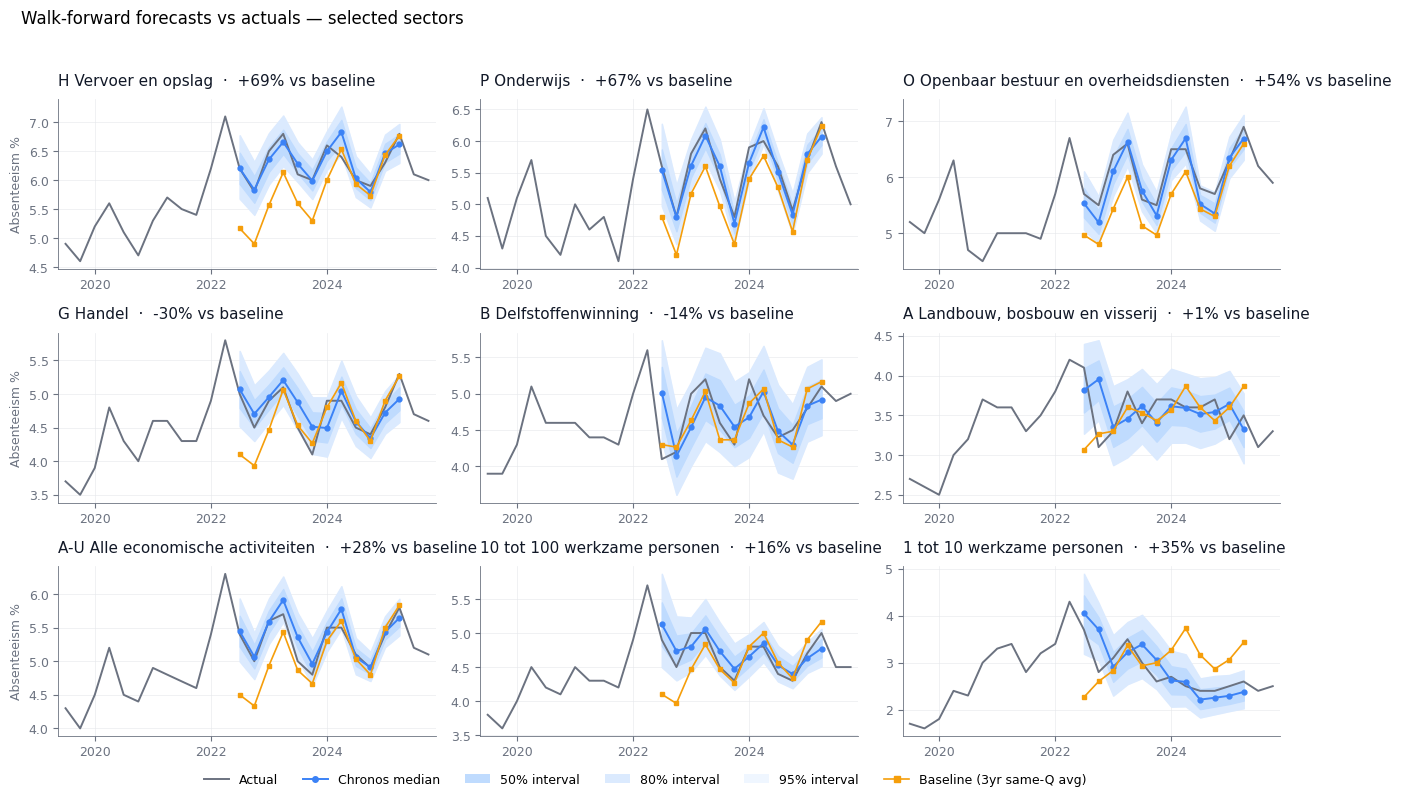

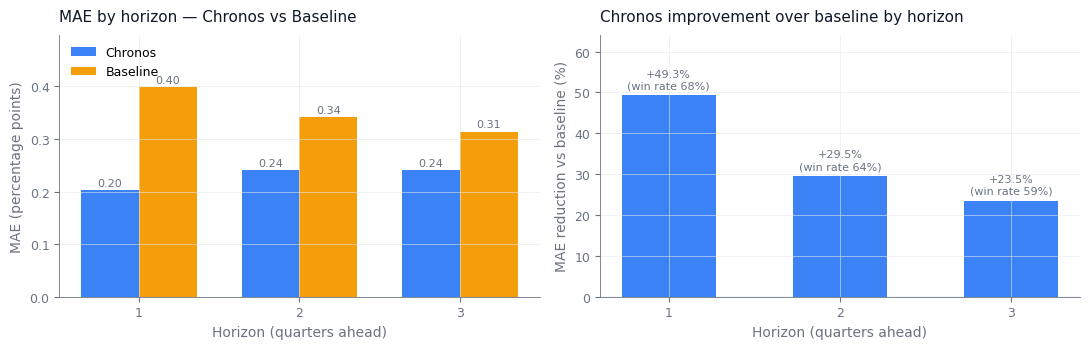

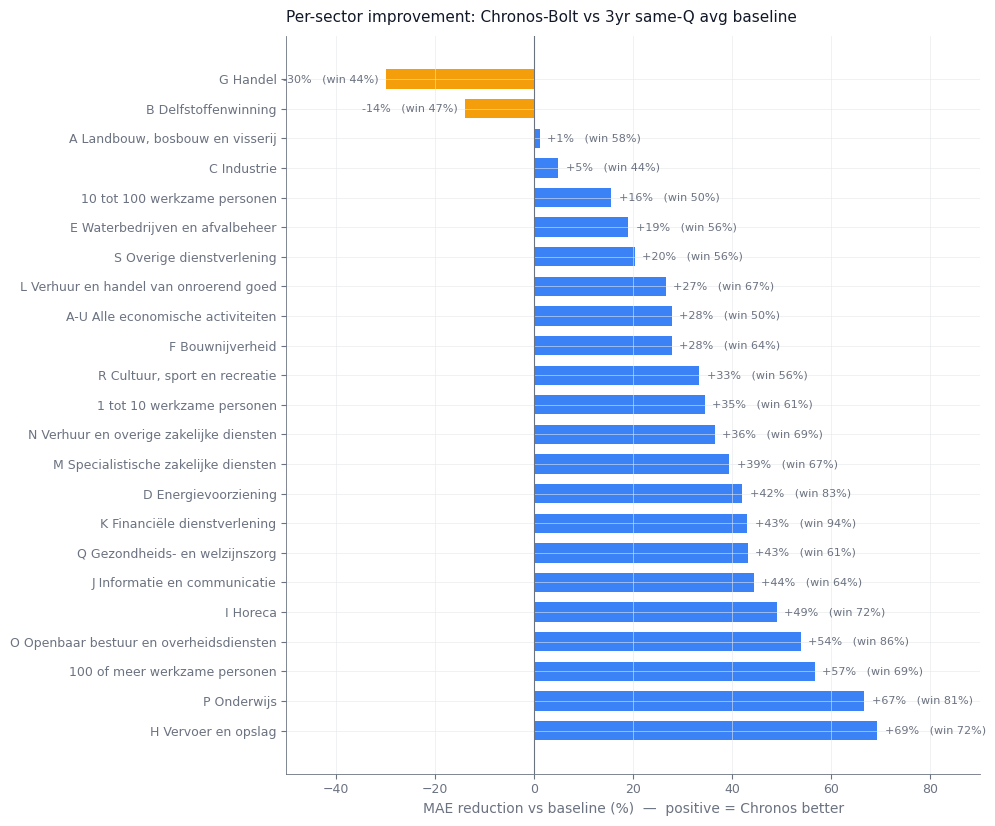

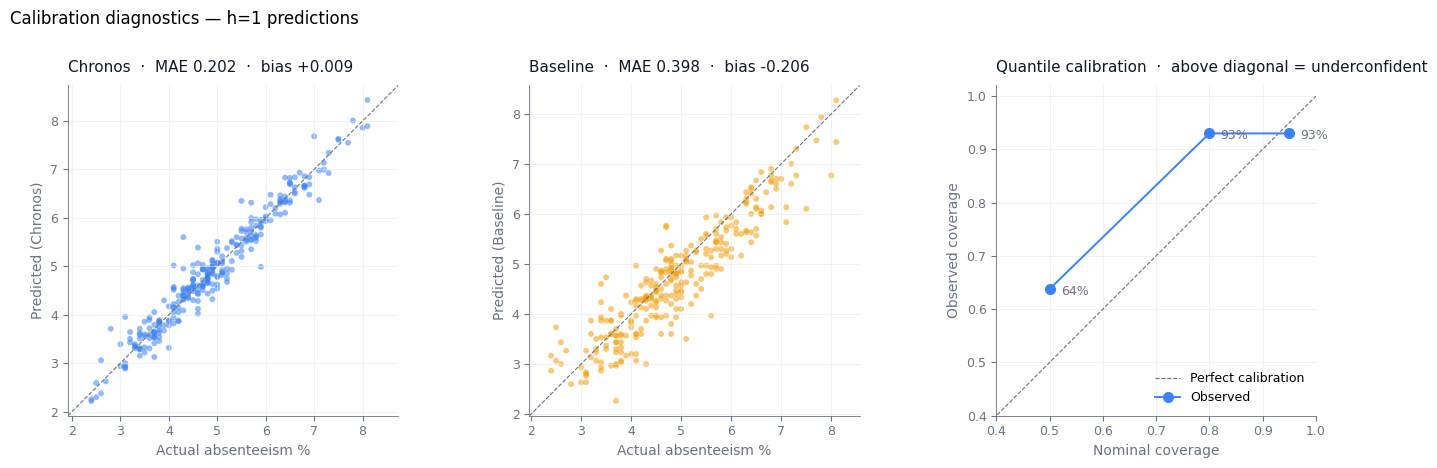

In [59]:
# ============================================================
# Section 9 — Visualization (Chronos vs Baseline, 50/80/95% bands)
# ============================================================
# ---- Palette ----
C_GREY    = "#6B7280"   # actuals / neutral / axes
C_BLUE    = "#3B82F6"   # Chronos median
C_ORANGE  = "#F59E0B"   # Baseline
C_BAND_50 = "#BFDBFE"   # darkest blue (50% interval)
C_BAND_80 = "#DBEAFE"   # mid blue
C_BAND_95 = "#EFF6FF"   # lightest blue
C_GRID    = "#E5E7EB"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    C_GREY,
    "axes.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        C_GRID,
    "grid.linewidth":    0.5,
    "grid.alpha":        0.8,
    "xtick.color":       C_GREY,
    "ytick.color":       C_GREY,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.labelcolor":   C_GREY,
    "axes.titlesize":    11,
    "axes.titleweight":  "regular",
    "axes.titlecolor":   "#111827",
    "axes.titlelocation":"left",
    "axes.titlepad":     10,
    "font.family":       "sans-serif",
    "legend.frameon":    False,
    "legend.fontsize":   9,
})

# ---- Sector code → title lookup ----
sector_titles = (
    df_baseline_all[["sbi_code", "sbi_title"]]
    .drop_duplicates()
    .set_index("sbi_code")["sbi_title"]
    .to_dict()
)

def label_for(sbi: str, max_len: int = 50) -> str:
    title = sector_titles.get(sbi, sbi)
    if len(title) > max_len:
        title = title[: max_len - 1] + "…"
    return title


# ============================================================
# Plot 1 — Fan charts: nested 50/80/95% bands + baseline overlay
# ============================================================
def plot_fan(ax, series: pd.Series, sector_df: pd.DataFrame, sector_label: str):
    s  = series.dropna()
    h1 = sector_df[sector_df["horizon"] == 1].sort_values("target_date")

    visible_start = h1["target_date"].min() - pd.DateOffset(years=3)
    s_vis = s[s.index >= visible_start]

    # Stacked bands: widest first (drawn lowest), narrowest last (drawn on top)
    ax.fill_between(h1["target_date"], h1["q02"], h1["q97"], color=C_BAND_95, zorder=1)
    ax.fill_between(h1["target_date"], h1["q10"], h1["q90"], color=C_BAND_80, zorder=2)
    ax.fill_between(h1["target_date"], h1["q25"], h1["q75"], color=C_BAND_50, zorder=3)

    # Actuals on top
    ax.plot(s_vis.index, s_vis.values, color=C_GREY, lw=1.4, zorder=5)

    # Chronos median
    ax.plot(h1["target_date"], h1["y_hat"],
            color=C_BLUE, lw=1.4, marker="o", ms=3.5, zorder=6)

    # Baseline overlay
    ax.plot(h1["target_date"], h1["baseline_prediction"],
            color=C_ORANGE, lw=1.2, marker="s", ms=3.0, zorder=6)

    ax.set_title(sector_label)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0.02)


# Curated set: 3 best, 3 worst (by % improvement vs baseline), total + size extremes
sector_metrics = metrics_by_sector_overall.set_index("sbi_code")
best   = sector_metrics.query("group == 'sbi_lvl1'").nlargest(3, "improvement_pct").index.tolist()
worst  = sector_metrics.query("group == 'sbi_lvl1'").nsmallest(3, "improvement_pct").index.tolist()
extras = ["T001081", "WP19091", "WP19078"]
selected = best + worst + extras
sector_to_group = bt.drop_duplicates("sbi_code").set_index("sbi_code")["group"].to_dict()

n_cols = 3
n_rows = int(np.ceil(len(selected) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.6 * n_rows))
axes = np.atleast_2d(axes)

for i, sbi in enumerate(selected):
    ax    = axes[i // n_cols, i % n_cols]
    grp   = sector_to_group[sbi]
    s     = SERIES_GROUPS[grp][sbi]
    sub   = bt[bt["sbi_code"] == sbi]
    impr  = sector_metrics.loc[sbi, "improvement_pct"]
    label = f"{label_for(sbi)}  ·  {impr:+.0f}% vs baseline"
    plot_fan(ax, s, sub, label)

for j in range(len(selected), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")

for r in range(n_rows):
    axes[r, 0].set_ylabel("Absenteeism %", fontsize=9)

handles = [
    plt.Line2D([0], [0], color=C_GREY,    lw=1.4, label="Actual"),
    plt.Line2D([0], [0], color=C_BLUE,    lw=1.4, marker="o", ms=4, label="Chronos median"),
    Patch(facecolor=C_BAND_50, edgecolor="none", label="50% interval"),
    Patch(facecolor=C_BAND_80, edgecolor="none", label="80% interval"),
    Patch(facecolor=C_BAND_95, edgecolor="none", label="95% interval"),
    plt.Line2D([0], [0], color=C_ORANGE,  lw=1.2, marker="s", ms=4, label="Baseline (3yr same-Q avg)"),
]
fig.legend(handles=handles, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Walk-forward forecasts vs actuals — selected sectors",
             fontsize=12, x=0.02, ha="left", y=1.0)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()


# ============================================================
# Plot 2 — Grouped MAE by horizon: Chronos vs Baseline + improvement
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

h_metrics = metrics_by_horizon.copy()
x = np.arange(len(h_metrics))
w = 0.36
horizons = h_metrics["horizon"].astype(str).tolist()

# (a) MAE side-by-side
axes[0].bar(x - w/2, h_metrics["MAE_chronos"],  width=w, color=C_BLUE,   label="Chronos")
axes[0].bar(x + w/2, h_metrics["MAE_baseline"], width=w, color=C_ORANGE, label="Baseline")
for i, (c, b) in enumerate(zip(h_metrics["MAE_chronos"], h_metrics["MAE_baseline"])):
    axes[0].text(i - w/2, c + 0.008, f"{c:.2f}", ha="center", color=C_GREY, fontsize=8)
    axes[0].text(i + w/2, b + 0.008, f"{b:.2f}", ha="center", color=C_GREY, fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(horizons)
axes[0].set_xlabel("Horizon (quarters ahead)")
axes[0].set_ylabel("MAE (percentage points)")
axes[0].set_title("MAE by horizon — Chronos vs Baseline")
axes[0].legend(loc="upper left")
axes[0].set_ylim(0, max(h_metrics["MAE_baseline"].max(), h_metrics["MAE_chronos"].max()) * 1.25)

# (b) Improvement % with win rate annotated
ax2 = axes[1]
ax2.bar(x, h_metrics["improvement_pct"], width=0.55,
        color=[C_BLUE if v > 0 else C_ORANGE for v in h_metrics["improvement_pct"]])
ax2.axhline(0, color=C_GREY, lw=0.8)
for i, (impr, wr) in enumerate(zip(h_metrics["improvement_pct"], h_metrics["win_rate_chronos"])):
    ax2.text(i, impr + (1.2 if impr >= 0 else -1.2),
             f"{impr:+.1f}%\n(win rate {wr:.0%})",
             ha="center", va="bottom" if impr >= 0 else "top",
             color=C_GREY, fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(horizons)
ax2.set_xlabel("Horizon (quarters ahead)")
ax2.set_ylabel("MAE reduction vs baseline (%)")
ax2.set_title("Chronos improvement over baseline by horizon")
ax2.set_ylim(min(0, h_metrics["improvement_pct"].min() * 1.5),
             h_metrics["improvement_pct"].max() * 1.3)

plt.tight_layout()
plt.show()


# ============================================================
# Plot 3 — Per-sector improvement (Chronos vs Baseline)
# ============================================================
sm = metrics_by_sector_overall.sort_values("improvement_pct", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 0.32 * len(sm) + 1))
bar_colors = [C_BLUE if v > 0 else C_ORANGE for v in sm["improvement_pct"]]
ax.barh(sm["sbi_code"].map(lambda c: label_for(c, max_len=80)),
        sm["improvement_pct"], color=bar_colors, height=0.65)
ax.axvline(0, color=C_GREY, lw=0.8)
ax.invert_yaxis()
ax.set_xlabel("MAE reduction vs baseline (%)  —  positive = Chronos better")
ax.set_title("Per-sector improvement: Chronos-Bolt vs 3yr same-Q avg baseline")

for i, row in sm.iterrows():
    val = row["improvement_pct"]
    offset = 1.5 if val >= 0 else -1.5
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, i,
            f"{val:+.0f}%   (win {row['win_rate_chronos']:.0%})",
            va="center", ha=ha, color=C_GREY, fontsize=8)

xmax = max(80, sm["improvement_pct"].max() * 1.3)
xmin = min(-50, sm["improvement_pct"].min() * 1.3)
ax.set_xlim(xmin, xmax)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 4 — Calibration: predicted vs actual (h=1) AND coverage diagnostic
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
h1 = bt[bt["horizon"] == 1]

# (a) Chronos calibration scatter
for ax, col, color, name in [
    (axes[0], "y_hat",               C_BLUE,   "Chronos"),
    (axes[1], "baseline_prediction", C_ORANGE, "Baseline"),
]:
    ax.scatter(h1["y_true"], h1[col], s=18, color=color, alpha=0.55, edgecolor="none")
    lo = min(h1["y_true"].min(), h1[col].min()) - 0.3
    hi = max(h1["y_true"].max(), h1[col].max()) + 0.3
    ax.plot([lo, hi], [lo, hi], color=C_GREY, lw=0.8, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    mae  = (h1[col] - h1["y_true"]).abs().mean()
    bias = (h1[col] - h1["y_true"]).mean()
    ax.set_xlabel("Actual absenteeism %")
    ax.set_ylabel(f"Predicted ({name})")
    ax.set_title(f"{name}  ·  MAE {mae:.3f}  ·  bias {bias:+.3f}")

# (c) Quantile coverage diagnostic — nominal vs observed
ax3 = axes[2]
nominal  = np.array([0.50, 0.80, 0.95])
observed = np.array([
    bt["in_q25_q75"].mean(),
    bt["in_q10_q90"].mean(),
    bt["in_q02_q97"].mean(),
])

ax3.plot([0, 1], [0, 1], color=C_GREY, lw=0.8, ls="--", label="Perfect calibration")
ax3.plot(nominal, observed, color=C_BLUE, lw=1.4, marker="o", ms=7, label="Observed")
for n, o in zip(nominal, observed):
    ax3.annotate(f"{o:.0%}", xy=(n, o), xytext=(8, -4),
                 textcoords="offset points", color=C_GREY, fontsize=9)
    ax3.annotate(f"nominal {n:.0%}", xy=(n, 0), xytext=(0, -18),
                 textcoords="offset points", ha="center", color=C_GREY, fontsize=8)

ax3.set_xlim(0.4, 1.0); ax3.set_ylim(0.4, 1.02)
ax3.set_aspect("equal")
ax3.set_xlabel("Nominal coverage")
ax3.set_ylabel("Observed coverage")
ax3.set_title("Quantile calibration  ·  above diagonal = underconfident")
ax3.legend(loc="lower right")

fig.suptitle("Calibration diagnostics — h=1 predictions",
             fontsize=12, x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()